In [1]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
reportable = pd.read_csv('(#path to#)reportable.csv', index_col='Unnamed: 0')

In [5]:
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']

In [7]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

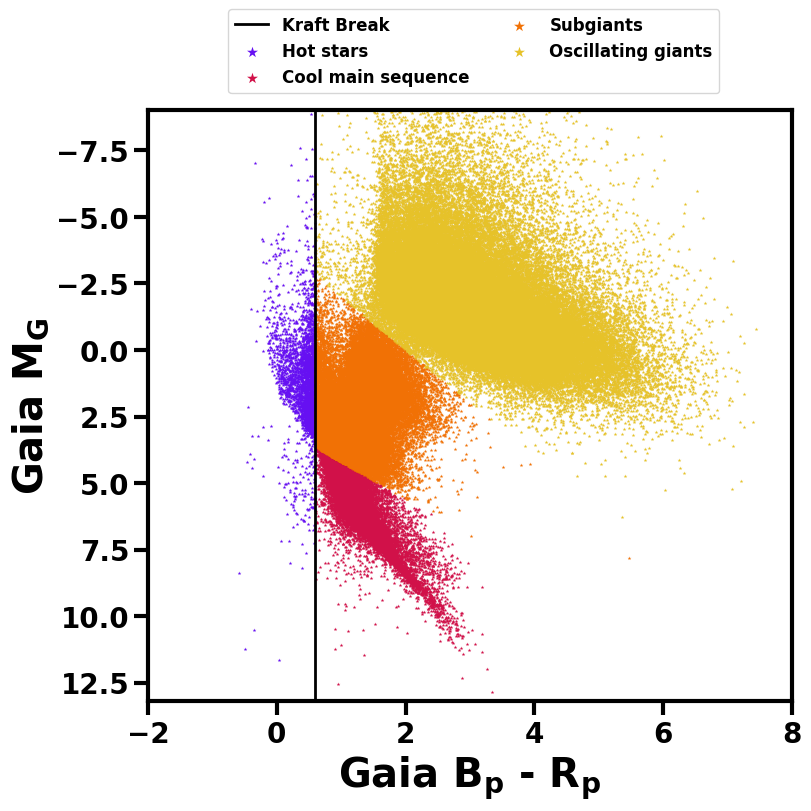

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8), layout='constrained')

axs.set_xlim(-2, 8)
axs.set_ylim(13.2, -9)
axs.set_xlabel(f'Gaia $\\bf B_p$ - $\\bf R_p$', weight='bold')
axs.set_ylabel(f'Gaia $\\bf M_G$', weight='bold')
axs.plot([0.6, 0.6], [15, -17], c="#000000", label="Kraft Break", rasterized=True, linewidth=2)
imhot = axs.scatter('bp-rp', 'abs_g_mag', c="#6610F2", s=7.5, marker="*", data=hot, linewidths=0.01, label='Hot stars', rasterized=True)
imms = axs.scatter('bp-rp', 'abs_g_mag', c="#D11149", s=7.5, marker="*", data=ms, linewidths=0.01, label='Cool main sequence', rasterized=True)
imsub = axs.scatter('bp-rp', 'abs_g_mag', c="#F17105", s=7.5, marker="*", data=subgiants,linewidths=0.01, label='Subgiants', rasterized=True)
imosc = axs.scatter('bp-rp', 'abs_g_mag', c="#E6C229", s=7.5, marker="*", data=oscillators, linewidths=0.01, label='Oscillating giants', rasterized=True)

axs.legend(loc='center right', ncols=2, markerscale=3,  bbox_to_anchor=(0.9, 1.1), fontsize=12)

plt.savefig('hrsubpopulations.pdf',  dpi=300)
plt.show()